## Exercise II: Monte Carlo Integration and Importance Sampling [Total: 15 Marks]

Consider the integral

\begin{equation}
    I = \int_0^1 \sin(\pi x(1-x))\mathrm{d}x = \mathbb{E}[X], \quad X=g(U), \quad g(U)=\sin(\pi U(1-U))
\end{equation}

where $U$ is a uniform random variable in $(0,1)$.



1.   Use Monte Carlo integration based on sampling $U$ to estimate $I$ with $1\sigma$ error at most $0.001$. How many samples do you need? (It is not necessary to automate this: trial and error is sufficient.) **[5 Marks]**
2.   Choose a random variable $Z$ on $(0,1)$ whose density resembles the integrand of $I$ and which you know how to sample efficiently (by inversion method, acceptance-rejection, or a built-in Python function). Estimate $I$ again using importance sampling, i.e. $I = \mathbb{E}[X']$ where $X' = g(Z) f_U(Z)/f_Z(Z)$, with an error of at most 0.001. How many samples did you need this time? Comment on the result. **[10 Marks]**


In [29]:
import numpy as np
import matplotlib.pyplot as plt
the_seed = 123
rng = np.random.default_rng(seed=the_seed)


# 2.1

We generate independent samples from the $ \text{Uniform}(0,1)$ distribution and compute the estimator
$$
\hat{I}_N = \frac{1}{N} \sum_{i=1}^N \sin\big(\pi U_i (1-U_i)\big).
$$

The standard error of the estimator is given by
$$
\text{SE} = \frac{\hat{\sigma}}{\sqrt{N}}
$$
where $\hat{\sigma}^2$ is the sample variance.

We increase the number of samples $N$ until the estimated standard error is at most $0.001$.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
the_seed = 123
rng = np.random.default_rng(seed=the_seed)

N= 100_000
U = rng.uniform(size=(N,1))

def g_fct(sample):
    return np.sin(np.pi*sample*(1-sample))
trans = g_fct(U)
def MC_est(sample):
    return np.mean(sample,axis=0), np.std(sample, axis=0, ddof=1)/np.sqrt(len(sample))

step = int(N/100)
x_axis = list(range(step,N,step))
std_list = []
for i in x_axis:
    std_list.append(MC_est(trans[:i])[1])

We need at least 43000 observations for the standard deviation to be below 0.001


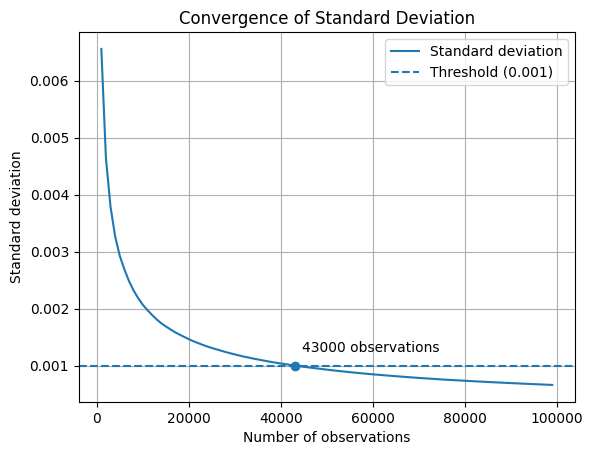

In [31]:
plt.figure()
threshold  = 0.001
x_axis = np.array(x_axis)
std_list = np.array(std_list)
ind = np.where(std_list < threshold)[0][0]
plt.plot(x_axis, std_list, label="Standard deviation")
plt.axhline(threshold, linestyle='--', label="Threshold (0.001)")
plt.scatter(x_axis[ind], std_list[ind])
plt.annotate(
    f"{x_axis[ind]} observations",
    (x_axis[ind], std_list[ind]),
    textcoords="offset points",
    xytext=(5,10)
)
plt.xlabel("Number of observations")
plt.ylabel("Standard deviation")
plt.title("Convergence of Standard Deviation")
plt.grid(True)
plt.legend()
print(f"We need at least {x_axis[ind]} observations for the standard deviation to be below {threshold}")
plt.show()

From the simulation, we observe that the standard error decreases as the number of samples $N$ increases, consistent with the theoretical rate
$$
\text{SE} \propto \frac{1}{\sqrt{N}}.
$$

From the plot, the standard error drops below the required threshold of $0.001$ at approximately
$$
N \approx 43{,}000.
$$

Thus, at least **43,000 samples** are required to achieve a $1\sigma$ error of at most $0.001$.

The curve shows a rapid decrease in error initially, followed by diminishing returns as $N$ becomes large. This behaviour is characteristic of Monte Carlo methods, where reducing error further requires disproportionately more samples.

# 2.2

Importance sampling can be used to reduce the variance of the original MC estimator. Importance sampling generates a sample from a different distribution than the original and then accounts for this by importance weights. 

It is defined as $f,g,h: \R^d\rightarrow \R$ where $f$ and $g$ are density functions that satisfy $f(x)>0\Rightarrow g(x)>0, \quad \forall x\in \R^d$ and $h$ is a function. The importance sampling estimator of 
$$
\mu_{IS_{n}}=\frac{1}{n}\sum_{i=1}^n h(Z_i)\frac{g(Z_i)}{f(Z_i)}
$$
where $X_1,...,X_n$ are i.i.d. random variables from density $f$. $w(Z_i)=\frac{f(Z_i)}{g(Z_i)}$ is refereed to as the importance weight.

$f(x)=1$ as it is the density function for a uniform variable, while $h(x)=\sin(\pi x(1-x))$. 

We therefore need to find $f(z)$ from which we can sample $Z$ from. As $X\sim \mathcal{U}(0,1)$, $X\in[0,1]$. Another distribution on the same domain is the beta distribution with the density
$$
f_Z(z) = \frac{z^{\alpha-1}(1-z)^{\beta-1}}{B(\alpha,\beta)}.
$$
Where $B(\alpha,\beta)=\frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$ and $\Gamma$ is the gamma function. By picking $\alpha=\beta=2$, $f_Z(z) = 6z(1-z)$, which highly resembles the inner function of $h(X)$. This $g_Z(z)$ satisfies $g(x)>0\Rightarrow f(x)>0, \quad \forall x\in [0,1]$. 

We can therefore easily efficiently sample $Z\sim B(2,2)$ and estimate $\mu_{IS_{n}}$

To minimize the noise from random samples, we only draw one time and extend the index.

In [32]:
def f_fct(Z):
    return 6*Z*(1-Z)
# draw from beta-distribution now
Z = rng.beta(2,2,size=N)
I_is = g_fct(Z)/f_fct(Z)
step = int(N/1000)
x_axis = list(range(step,N,step))
std_list_1 = []
std_list_2 = []
for i in x_axis:
    std_list_1.append(MC_est(trans[:i])[1])
    std_list_2.append(MC_est(I_is[:i])[1])

We need at least 300 observations for method 2 to reach std < 0.001


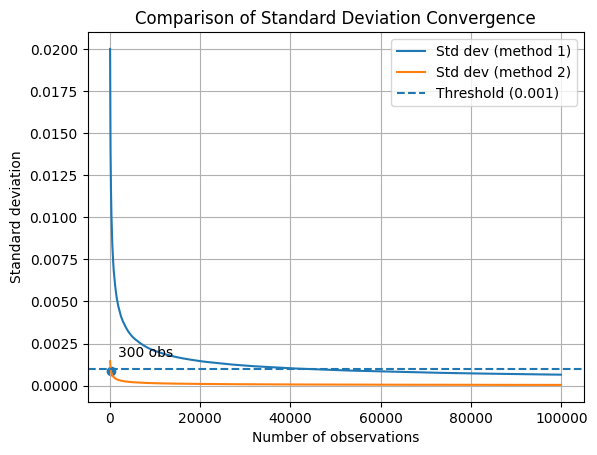

In [33]:
x_axis = np.array(x_axis)
std1 = np.array(std_list_1)
std2 = np.array(std_list_2)
threshold = 0.001
ind = np.where(std2 < threshold)[0][0]

plt.figure()
plt.plot(x_axis, std1, label="Std dev (method 1)")
plt.plot(x_axis, std2, label="Std dev (method 2)")
plt.axhline(threshold, linestyle='--', label="Threshold (0.001)")
plt.scatter(x_axis[ind], std2[ind])
plt.annotate(
    f"{x_axis[ind]} obs",
    (x_axis[ind], std2[ind]),
    textcoords="offset points",
    xytext=(5,10)
)
plt.xlabel("Number of observations")
plt.ylabel("Standard deviation")
plt.title("Comparison of Standard Deviation Convergence")
plt.grid(True)
plt.legend()
print(f"We need at least {x_axis[ind]} observations for method 2 to reach std < {threshold}")
plt.show()

From the plot, we observe that the standard error decreases much more rapidly compared to standard Monte Carlo.

The required accuracy of $0.001$ is achieved at approximately
$$
N \approx 300.
$$

Thus, only **around 300 samples** are needed when using importance sampling, compared to approximately $43{,}000$ samples for standard Monte Carlo.

The estimated integral stabilises quickly, and the variance is significantly smaller across all sample sizes.

The improvement occurs because the proposal distribution
$$
f_Z(x) = 6x(1-x)
$$
closely matches the shape of the integrand, concentrating samples near $x = 0.5$, where $\sin(\pi x(1-x))$ is largest.

As a result, the variance of the estimator is greatly reduced, leading to much faster convergence.

In contrast, uniform sampling wastes many samples in regions where the integrand is small, making it inefficient.
